In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
## Exercise 5.5
# Heston stochastic volatility model from modeling-volatility:
def simulate_stochastic_volatility(S, r, q, dt, N, kappa, theta, gamma, rho, sigma0, n):
    """ 
    S = initial price
    r = risk-free rate
    q = dividend yield
    dt = time increment
    N = number of time periods
    kappa = reversion rate perameter
    gamma = change in delta with S
    rho = correlation between z and z*
    sigma0 = initial volatility
    n = number of simulations

    returns array of simulated logS(T) values using Heston stochastic volatility
    """

    logST = []

    for i in range(n):
        LogS = np.log(S)
        var = sigma0**2
        sigma = sigma0

        for j in range(N):
            z1 = np.random.randn()
            z2 = np.random.randn()
            zStar = rho * z1 + np.sqrt(1 - rho**2) * z2

            LogS += (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z1

            logST.append(LogS)

    return logST


def monte_carlo_heston_european_call(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M):
    """
    S = initial price
    K = strike price
    r = risk-free rate
    q = dividend yield
    T = time to maturity
    N = number of time periods
    kappa = reversion rate parameter
    theta = unconditional variance
    gamma = change in delta with S
    rho = correlation between z and z*
    sigma0 = initial volatility
    M = number of simulations

    returns value and std. error of European call option from Monte Carlo simulation
    """

    dt = T / N 
    logST = simulate_stochastic_volatility(S, r, q, dt, N, kappa, theta, gamma, rho, sigma0, M)

    payoffs = np.maximum(np.exp(logST) - K, 0)
    discounted_payoffs = np.exp(-r*T)*payoffs

    option_value = np.mean(discounted_payoffs)
    option_value_error = np.std(discounted_payoffs) / np.sqrt(M)

    return option_value, option_value_error

In [8]:
# Set parameters
S = 100         
K = 100         
r = 0.05        
q = 0.02        
T = 1           
N = 100         
kappa = 2.0     
theta = 0.04    
gamma = 0.3     
rho = -0.5      
sigma0 = 0.2    
M = 10000       

option_value, std_error = monte_carlo_heston_european_call(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M)
print("Estimated Option Value:", option_value)
print("Standard Error:", std_error)

Estimated Option Value: 5.821959185782447
Standard Error: 0.09595177239988749


In [ ]:
## Exercise 5.6
# Modifying previous function to estimate delta
def monte_carlo_heston_european_call_delta(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M, epsilon):
    """
    S = initial price
    K = strike price
    r = risk-free rate
    q = dividend yield
    T = time to maturity
    N = number of time periods
    kappa = reversion rate parameter
    theta = unconditional variance
    gamma = change in delta with S
    rho = correlation between z and z*
    sigma0 = initial volatility
    M = number of simulations
    epsilon = small incriment to change path and estimate greeks

    returns value and std. error of European call option from Monte Carlo simulation 
    AND the delta and std. error of the delta for the option
    """

    dt = T / N 
    logST = simulate_stochastic_volatility(S, r, q, dt, N, kappa, theta, gamma, rho, sigma0, M)
    logST_epsilon = simulate_stochastic_volatility(S + epsilon, r, q, dt, N, kappa, theta, gamma, rho, sigma0, M)

    payoffs = np.maximum(np.exp(logST) - K, 0)
    payoffs_epsilon = np.maximum(np.exp(logST_epsilon) - K, 0)

    discounted_payoffs = np.exp(-r*T)*payoffs
    discounted_payoffs_epsilon = np.exp(-r*T)*payoffs_epsilon

    option_value = np.mean(discounted_payoffs)
    option_value_error = np.std(discounted_payoffs) / np.sqrt(M)

    delta = np.mean((discounted_payoffs_epsilon - discounted_payoffs) / epsilon)
    delta_std_error = np.std((discounted_payoffs_epsilon - discounted_payoffs) / epsilon) / np.sqrt(M)

    return option_value, option_value_error, delta, delta_std_error

In [10]:
# Set parameters
S = 100         
K = 100         
r = 0.05        
q = 0.02        
T = 1           
N = 100         
kappa = 2.0     
theta = 0.04    
gamma = 0.3     
rho = -0.5      
sigma0 = 0.2    
M = 10000
epsilon = 0.0001        

option_value, std_error, delta, delta_error = monte_carlo_heston_european_call_delta(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M, epsilon)
print("Estimated Option Value:", option_value)
print("Standard Error:", std_error)
print("Delta:", delta)
print("Delta Std. Error:", delta_error)

Estimated Option Value: 5.970831699166405
Standard Error: 0.09671778733039098
Delta: -440.52599810475857
Delta Std. Error: 1340.3045108432211


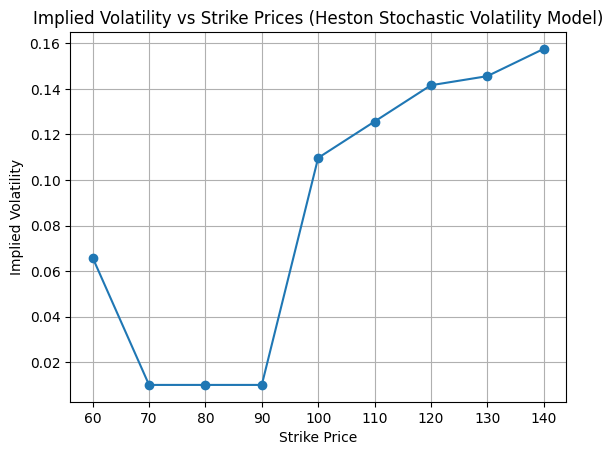

In [12]:
## Exercise 5.7
# Black-Scholes call option pricing function
def black_scholes_call(S, K, r, sigma, q, T):
    if sigma == 0:
        black_scholes_price = max(0, np.exp(-q*T)*S - np.exp(-r*T)*K)
    else:
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        N1 = norm.cdf(d1)
        N2 = norm.cdf(d2)
        black_scholes_price = np.exp(-q*T)*S*N1 - np.exp(-r*T)*K*N2

    return black_scholes_price

# Implied volatility function provided
def implied_volatility_grid(S, K, r, q, T, S_mkt):
    volatilities = np.linspace(0.01, 2, 500)  # Search range for volatilities
    min_diff = float(9999999999)
    implied_vol = 0.01

    # Search for implied volatility
    for sigma in volatilities:
        price = black_scholes_call(S, K, r, sigma, q, T)
        diff = abs(price - S_mkt)
        if diff < min_diff:
            min_diff = diff
            implied_vol = sigma 

    return implied_vol

# Set parameters
S = 100         
r = 0.05         
q = 0.02         
T = 1            
N = 100          
kappa = 0.2      
theta = 0.04     
gamma = 0.3
rho = -0.5
sigma0 = 0.2       
M = 10000      

# Strike prices to loop through
strike_prices = np.array([0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]) * S

# Arrays to store results
call_prices = []
implied_vols = []

monte_carlo_heston_european_call(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M)

# Loop over strike prices and compute Heston MC call prices and implied volatilities
for K in strike_prices:
    call_price, std_error = monte_carlo_heston_european_call(S, K, r, q, T, N, kappa, theta, gamma, rho, sigma0, M)
    call_prices.append(call_price)

    implied_vol = implied_volatility_grid(S, K, r, q, T, call_price)
    implied_vols.append(implied_vol)

# Convert results to numpy arrays
call_prices = np.array(call_prices)
implied_vols = np.array(implied_vols)

# Plot implied volatilities against strike prices
plt.plot(strike_prices, implied_vols, marker='o')
plt.title("Implied Volatility vs Strike Prices (Heston Stochastic Volatility Model)")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()

In [13]:
## Exercise 6.1

def monte_carlo_foreign_asset_options(X0, S0, K, r, rf, sigmaX, sigmaS, rho, q, T, N):
    """
    X0 = initial foreign exchange rate
    S0 = initial asset price (in foreign currency)
    K = strike price (in foreign currency)
    r = domestic risk-free rate
    rf = foreign risk-free rate
    sigmaX = volatility of exchange rate
    sigmaS = volatiltiy of asset
    rho = correlation between asset and exchange rate
    q = dividend yield of asset
    T = time to maturity
    M = number of simulations

    returns value of the call option in both foreign and domestic currency
    """

    dt = T
    discount = np.exp(-r*T)

    foreign_payoffs = []
    domestic_payoffs = []

    for i in range(M):
        z1 = np.random.randn()
        z2 = np.random.randn()

        zX = z1
        zS = rho * z1 + np.sqrt(1-rho**2) * z2

        XT = X0 * np.exp((r - rf - 0.5 * sigmaX**2)*dt + sigmaX * np.sqrt(dt) * zX)
        ST = S0 * np.exp((r - rf - 0.5 * sigmaS**2)*dt + sigmaS * np.sqrt(dt) * zS)

        foreign_payoff = np.maximum(ST - K, 0)
        foreign_payoffs.append(foreign_payoff)

        domestic_payoff = np.maximum(XT * ST - X0 * K, 0)
        domestic_payoffs.append(domestic_payoff)

    
    foreign_option_value = discount * np.mean(foreign_payoffs)
    domestic_option_value = discount * np.mean(domestic_payoffs)

    return foreign_option_value, domestic_option_value

In [15]:
# Set parameters
X0 = 1.2      
S0 = 100      
K = 100       
r = 0.05      
rf = 0.05     
sigmaX = 0.15 
sigmaS = 0.2  
rho = 0.5     
q = 0.02      
T = 1         
M = 10000     

# Compute the values of the options
foreign_option_value, domestic_option_value = monte_carlo_foreign_asset_options(X0, S0, K, r, rf, sigmaX, sigmaS, rho, q, T, M)
print("Call option in foreign currency:", foreign_option_value)
print("Call option in domestic currency:", domestic_option_value)

Call option in foreign currency: 7.629826869720927
Call option in domestic currency: 15.045403178434123


In [16]:
## Exercise 6.2

def monte_carlo_foreign_vs_quanto(X0, S0, K, r, rf, sigmaX, sigmaS, rho, q, T, M):
    """
    X0 = initial foreign exchange rate
    S0 = initial asset price (in foreign currency)
    K = strike price (in foreign currency)
    r = domestic risk-free rate
    rf = foreign risk-free rate
    sigmaX = volatility of exchange rate
    sigmaS = volatiltiy of asset
    rho = correlation between asset and exchange rate
    q = dividend yield of asset
    T = time to maturity
    M = number of simulations

    returns the value of the call option in foreign currency and the quanto option
    """

    dt = T
    discount = np.exp(-r*T)

    foreign_payoffs = []
    quanto_payoffs = []

    for i in range(M):
        z1 = np.random.randn()
        z2 = np.random.randn()

        zX = z1
        zS = rho * z1 + np.sqrt(1-rho**2) * z2

        XT = X0 * np.exp((r - rf - 0.5 * sigmaX**2) * dt + sigmaX * np.sqrt(dt) * zX)
        ST = S0 * np.exp((r - rf - 0.5 * sigmaS**2) * dt + sigmaS * np.sqrt(dt) * zS)

        foreign_payoff = np.maximum(ST - K, 0)
        foreign_payoffs.append(foreign_payoff)

        quanto_payoff = X0 * np.maximum(ST - K, 0)
        quanto_payoffs.append(quanto_payoff)

    foreign_option_value = discount * np.mean(foreign_payoffs)
    quanto_option_value = discount * np.mean(quanto_payoffs)

    return foreign_option_value, quanto_option_value

In [21]:
# Set parameters
X0 = 1.2      
S0 = 100      
K = 100       
r = 0.05      
rf = 0.05  
sigmaX = 0.15 
sigmaS = 0.2  
rho = 0.5     
q = 0.02      
T = 1         
M = 10000     

# Compute the values of the options
foreign_option_value, quanto_option_value = monte_carlo_foreign_vs_quanto(X0, S0, K, r, rf, sigmaX, sigmaS, rho, q, T, M)
print("Call option in foreign currency:", foreign_option_value)
print("Quanto call option value:", quanto_option_value)

Call option in foreign currency: 7.5741444278315475
Quanto call option value: 9.088973313397856


In [22]:
## Exercise 6.3

def compute_forward_rate(r, rf, X0, T):
    """
    r = domestic risk-free rate
    rf = foreign risk-free rate
    X0 = initial exchange rate
    T = time to maturity

    returns forward exchange rate at time T
    """

    FT = X0 * np.exp((r - rf) * T)

    return FT

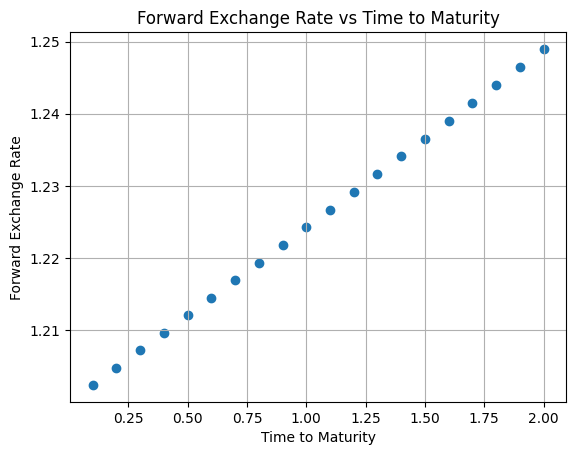

In [24]:
# Set parameters
r = 0.05
rf = 0.03
X0 = 1.2

T_values = np.arange(0.1, 2.1, 0.1)
forward_rates = [compute_forward_rate(r, rf, X0, T) for T in T_values]

# Plot the forward exchange rate against time to maturity
plt.scatter(T_values, forward_rates, label='Forward Rate')
plt.title('Forward Exchange Rate vs Time to Maturity')
plt.xlabel('Time to Maturity')
plt.ylabel('Forward Exchange Rate')
plt.grid(True)
plt.show()